# Compare Auction Values

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

In [98]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [99]:
Format_Avg_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Ottoneu/Latest_Ottoneu_4x4.csv'

In [100]:
League_Proj_files = {
    'Hitter_SGP':League_path+'Latest_Hitter_Proj.csv',
    'Pitcher_SGP':League_path+'Latest_Pitcher_Proj.csv',
    'FG_Auction_Hitter':League_path+'FG_Auction_Jan25_2026/fangraphs-auction-calculator_Hitters.csv',
    'FG_Auction_Pitcher':League_path+'FG_Auction_Jan25_2026/fangraphs-auction-calculator_Pitchers.csv',
    'Vibbot':League_path+'Vibbot_ATC_Proj_Jan26_2026.csv',
    'Ottoneu':Format_Avg_path,
    'Rosters':League_path+'Current_League_Rosters.csv'
}

In [101]:
Player_id_cols = [
    'FG ID','MLBAMID','Name','Team','NameASCII','Ottoneu ID','Ottoneu Positions'
]

In [102]:
Full_Merge_df = pd.DataFrame()

In [103]:
Player_ID_Map_Path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Player_ID_Map/Latest_Player_ID_Map.csv'

In [104]:
Player_ID_Map_df = pd.read_csv(Player_ID_Map_Path)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].astype(str)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].fillna(Player_ID_Map_df['FG Minor ID'])
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].str.replace('.0','')
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].astype(str)
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].str.replace('.0','')

# My SGP Proj

In [105]:
Hitter_SGP_df = pd.read_csv(League_Proj_files['Hitter_SGP'])
Pitcher_SGP_df = pd.read_csv(League_Proj_files['Pitcher_SGP'])
Hitter_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
Pitcher_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)

In [106]:
Hitter_SGP_df = Hitter_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
Pitcher_SGP_df = Pitcher_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [107]:
Hitter_Pitcher_SGP_df = pd.concat(
    [
        Hitter_SGP_df,
        Pitcher_SGP_df
    ]
)

In [108]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
150,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.5648,675.76,576.206,164.76240,82.63564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,22.1428,NaN,NaN,87.13748,NaN,...,0.547491,0.502314,0.832653,0.603944,0.865567,0.801932,12.890521,14.69341,17.231134,19.023178


In [109]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
150,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.5648,675.76,576.206,164.76240,82.63564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,22.1428,NaN,NaN,87.13748,NaN,...,0.547491,0.502314,0.832653,0.603944,0.865567,0.801932,12.890521,14.69341,17.231134,19.023178


In [110]:
Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755'].columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'W', 'L', 'QS', 'G',
       'GS', 'SV', 'HLD', 'IP', 'TBF', 'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'SO',
       'WAR', 'ADP', 'POS', 'K', 'HR9', 'ERA', 'WHIP', 'Pos Place',
       'K_SGP_raw', 'HR9_SGP_raw', 'ERA_SGP_raw', 'WHIP_SGP_raw',
       'TOTAL_SGP_raw', 'K_SGP_norm', 'HR9_SGP_norm', 'ERA_SGP_norm',
       'WHIP_SGP_norm', 'TOTAL_SGP', 'TOTAL_SGP_Rank', 'TOTAL_SGP_Val',
       'K_SGP_Val', 'HR9_SGP_Val', 'ERA_SGP_Val', 'WHIP_SGP_Val', 'Ottoneu ID',
       'Ottoneu Positions'],
      dtype='str')

In [111]:
#Handle Othtani...
Ohtani_df = pd.DataFrame([
    {
        'FG ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['FG ID'].values[0],
        'MLBAMID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['MLBAMID'].values[0],
        'Name':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Name'].values[0],
        'Team':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Team'].values[0],
        'NameASCII':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['NameASCII'].values[0],
        'G':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['G'].values[0],
        'PA':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['PA'].values[0],
        'AB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['AB'].values[0],
        'H':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['H'].values[0],
        '1B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['1B'].values[0], 
        '2B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['2B'].values[0], 
        '3B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['3B'].values[0],
        'HR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR'].values[0],
        'R':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R'].values[0],
        'RBI':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['RBI'].values[0],
        'BB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['BB'].values[0],
        'HBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HBP'].values[0],
        'SF':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SF'].values[0],
        'WAR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['WAR'].values[0],
        'ADP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['ADP'].values[0],
        'POS':"['DH','SP']",
        'OBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP'].values[0], 
        'TB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['TB'].values[0], 
        'SLG':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG'].values[0], 
        'Pos Place':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Pos Place'].values[0], 
        'R_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_raw'].values[0], 
        'HR_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_raw'].values[0],
        'OBP_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_raw'].values[0], 
        'SLG_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_raw'].values[0], 
        'TOTAL_SGP_raw':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_raw'].sum(), 
        'R_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_norm'].values[0],
        'HR_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_norm'].values[0], 
        'OBP_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_norm'].values[0], 
        'SLG_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_norm'].values[0], 
        'TOTAL_SGP':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP'].sum(),
        'TOTAL_SGP_Rank':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Rank'].min(), 
        'R_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_Val'].values[0], 
        'HR_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_Val'].values[0],
        'OBP_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_Val'].values[0], 
        'SLG_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_Val'].values[0],
        'W':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['W'].values[0], 
        'L':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['L'].values[0], 
        'QS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['QS'].values[0], 
        #'G':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['G'].values[0],
        'GS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['GS'].values[0], 
        'SV':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SV'].values[0], 
        'HLD':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HLD'].values[0], 
        'IP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['IP'].values[0], 
        'TBF':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['TBF'].values[0], 
        #'H':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['H'].values[0], 
        #'R':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['R'].values[0], 
        'ER':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ER'].values[0], 
        #'HR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR'].values[0], 
        #'BB':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['BB'].values[0], 
        #'HBP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HBP'].values[0], 
        'SO':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO'].values[0],
        #'WAR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WAR'].values[0], 
        #'ADP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ADP'].values[0], 
        #'POS':"['DH','SP']", 
        #'K':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K'].values[0], 
        'HR9':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9'].values[0], 
        'ERA':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA'].values[0], 
        'WHIP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP'].values[0], 
        #'Pos Place':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['Pos Place'].values[0],
        'K_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K_SGP_raw'].values[0], 
        'HR9_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_raw'].values[0],
        'ERA_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_raw'].values[0], 
        'WHIP_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_raw'].values[0],
        #'TOTAL_SGP_raw', 
        'K_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K_SGP_norm'].values[0], 
        'HR9_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_norm'].values[0], 
        'ERA_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_norm'].values[0],
        'WHIP_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_norm'].values[0], 
        #'TOTAL_SGP', 
        #'TOTAL_SGP_Rank', 
        'K_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K_SGP_Val'].values[0], 
        'HR9_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_Val'].values[0], 
        'ERA_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_Val'].values[0], 
        'WHIP_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_Val'].values[0],
        'TOTAL_SGP_Val':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Val'].sum(),
        'Ottoneu ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu ID'].values[0],
        'Ottoneu Positions':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu Positions'].values[0],
    }
])

In [112]:
Hitter_Pitcher_SGP_df.drop_duplicates(['FG ID'],keep=False,inplace=True)

In [113]:
Hitter_Pitcher_SGP_df = pd.concat([
    Hitter_Pitcher_SGP_df,
    Ohtani_df
])

In [114]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
0,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.5648,675.76,576.206,164.7624,82.63564,...,0.547491,0.502314,0.832653,0.603944,0.865567,0.801932,12.890521,14.69341,17.231134,19.023178


In [115]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [116]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val != 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [117]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [118]:
Full_Merge_df = Hitter_Pitcher_SGP_df.rename(columns={c: c+'_mySGP' for c in Hitter_Pitcher_SGP_df.columns if c not in Player_id_cols})

In [119]:
Full_Merge_df.sort_values('TOTAL_SGP_Val_mySGP',ascending=False).head()

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,ERA_SGP_raw_mySGP,WHIP_SGP_raw_mySGP,K_SGP_norm_mySGP,HR9_SGP_norm_mySGP,ERA_SGP_norm_mySGP,WHIP_SGP_norm_mySGP,K_SGP_Val_mySGP,HR9_SGP_Val_mySGP,ERA_SGP_Val_mySGP,WHIP_SGP_Val_mySGP
0,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.56480,675.7600,576.2060,164.76240,82.63564,...,0.547491,0.502314,0.832653,0.603944,0.865567,0.801932,12.890521,14.693410,17.231134,19.023178
52,15640,592450,Aaron Judge,NYY,Aaron Judge,153.02520,662.0624,537.9496,160.61800,82.23712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270,22267,669373,Tarik Skubal,DET,Tarik Skubal,31.15064,NaN,NaN,153.77000,NaN,...,1.488411,1.573518,3.029732,1.427072,1.806487,1.873136,46.904098,34.719347,35.962360,44.433943
551,31757,695243,Mason Miller,SDP,Mason Miller,64.23908,NaN,NaN,39.24188,NaN,...,2.242080,2.141107,0.739953,1.220455,2.998724,2.937063,11.455406,29.692548,59.696629,69.672084
144,19611,665489,Vladimir Guerrero Jr.,TOR,Vladimir Guerrero Jr.,156.36600,676.0260,588.6444,176.88760,110.61760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
Full_Merge_df.shape

(2661, 69)

# FanGraphs Auction Proj

In [121]:
FG_Auction_Hitter_df = pd.read_csv(League_Proj_files['FG_Auction_Hitter'])
FG_Auction_Pitcher_df = pd.read_csv(League_Proj_files['FG_Auction_Pitcher'])
FG_Auction_Hitter_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
FG_Auction_Pitcher_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)

In [122]:
FG_Auction_Hitter_df = FG_Auction_Hitter_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
FG_Auction_Pitcher_df = FG_Auction_Pitcher_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [123]:
Auction_Hitter_FGAV_df = pd.concat(
    [
        FG_Auction_Hitter_df,
        FG_Auction_Pitcher_df
    ]
)

In [124]:
Auction_Hitter_FGAV_df = Auction_Hitter_FGAV_df.rename(columns={c: c+'_FGAV' for c in Auction_Hitter_FGAV_df.columns if c not in Player_id_cols})

In [125]:
Auction_Hitter_FGAV_df.shape

(1336, 20)

In [126]:
Full_Merge_df = Full_Merge_df.merge(Auction_Hitter_FGAV_df,how='outer')

In [127]:
Full_Merge_df.shape

(2958, 83)

In [128]:
Full_Merge_df.head()

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mHR_FGAV,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV
0,10028,542194,Christian Bethancourt,CHC,Christian Bethancourt,0.00000,1.000,1.0000,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10061,548384,Brooks Raley,NYM,Brooks Raley,60.69940,NaN,NaN,50.97252,NaN,...,3.187338,NaN,NaN,-9.286891,4.116524,-4.170368,62.0,-3.315807,-4.81187,-4.346552
2,10078,573204,Caleb Thielbar,CHC,Caleb Thielbar,65.70708,NaN,NaN,54.63908,NaN,...,2.298006,NaN,NaN,-5.103909,4.116524,0.012615,66.0,-1.814045,-2.19632,-3.391550
3,10155,545361,Mike Trout,LAA,Mike Trout,129.14440,556.382,472.4704,113.94320,65.56196,...,-1.234562,1.264660,-0.850869,-6.752348,19.399045,13.646698,NaN,NaN,NaN,NaN
4,10231,578428,Jose Iglesias,NaN,Jose Iglesias,NaN,NaN,NaN,NaN,NaN,...,-17.572175,-2.273437,-5.122796,-45.442144,19.179833,-25.262311,NaN,NaN,NaN,NaN


<Axes: xlabel='Dollars_FGAV', ylabel='TOTAL_SGP_Val_mySGP'>

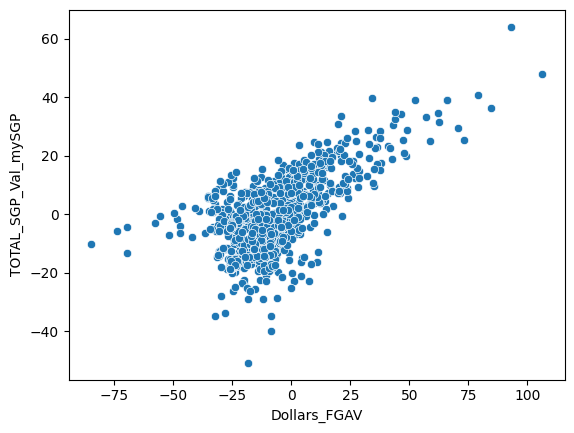

In [129]:
import seaborn as sns
sns.scatterplot(Full_Merge_df,x='Dollars_FGAV',y='TOTAL_SGP_Val_mySGP')

In [130]:
Full_Merge_df['Ottoneu ID']

0       18048
1        4970
2        6225
3        6305
4        5098
        ...  
2953    32579
2954    32716
2955    33058
2956    37530
2957    33510
Name: Ottoneu ID, Length: 2958, dtype: str

In [131]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mHR_FGAV,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV


In [132]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mHR_FGAV,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV


# Vibbot ATC

In [133]:
Vibbot_ATC_df = pd.read_csv(League_Proj_files['Vibbot'])
Vibbot_ATC_df.rename(columns={'otto':'Ottoneu ID','$':'Dollars_Vibbot'},inplace=True)

In [134]:
Vibbot_ATC_df.dropna(subset=['Ottoneu ID'],inplace=True)

In [135]:
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].astype(str)
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].str.replace('.0','')

In [136]:
Vibbot_ATC_df.head()

,Ottoneu ID,Name,Team,Pos,Dollars_Vibbot
0,33600,Shohei Ohtani,LAD,Util,80.4
1,18312,Aaron Judge,NYY,OF,68.9
2,23717,Juan Soto,NYM,OF,56.8
3,43894,Paul Skenes,PIT,SP,54.8
4,35204,Tarik Skubal,DET,SP,54.2


In [137]:
Vibbot_ATC_df = Vibbot_ATC_df[['Ottoneu ID','Dollars_Vibbot']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [138]:
Vibbot_ATC_df.columns

Index(['Ottoneu ID', 'Dollars_Vibbot', 'FG ID', 'Ottoneu Positions', 'Name'], dtype='str')

In [139]:
Vibbot_ATC_df.head()

,Ottoneu ID,Dollars_Vibbot,FG ID,Ottoneu Positions,Name
0,33600,80.4,19755,Util/SP,Shohei Ohtani
1,18312,68.9,15640,OF,Aaron Judge
2,23717,56.8,20123,OF,Juan Soto
3,43894,54.8,33677,SP,Paul Skenes
4,35204,54.2,22267,SP,Tarik Skubal


In [140]:
Full_Merge_df = Full_Merge_df.merge(Vibbot_ATC_df,how='outer')

In [141]:
Full_Merge_df.shape

(2958, 84)

In [142]:
Full_Merge_df.head()

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot
0,10028,542194,Christian Bethancourt,CHC,Christian Bethancourt,0.00000,1.000,1.0000,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10061,548384,Brooks Raley,NYM,Brooks Raley,60.69940,NaN,NaN,50.97252,NaN,...,NaN,NaN,-9.286891,4.116524,-4.170368,62.0,-3.315807,-4.81187,-4.346552,NaN
2,10078,573204,Caleb Thielbar,CHC,Caleb Thielbar,65.70708,NaN,NaN,54.63908,NaN,...,NaN,NaN,-5.103909,4.116524,0.012615,66.0,-1.814045,-2.19632,-3.391550,NaN
3,10155,545361,Mike Trout,LAA,Mike Trout,129.14440,556.382,472.4704,113.94320,65.56196,...,1.264660,-0.850869,-6.752348,19.399045,13.646698,NaN,NaN,NaN,NaN,20.6
4,10231,578428,Jose Iglesias,NaN,Jose Iglesias,NaN,NaN,NaN,NaN,NaN,...,-2.273437,-5.122796,-45.442144,19.179833,-25.262311,NaN,NaN,NaN,NaN,NaN


In [143]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot


In [144]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot


<Axes: xlabel='Dollars_Vibbot', ylabel='TOTAL_SGP_Val_mySGP'>

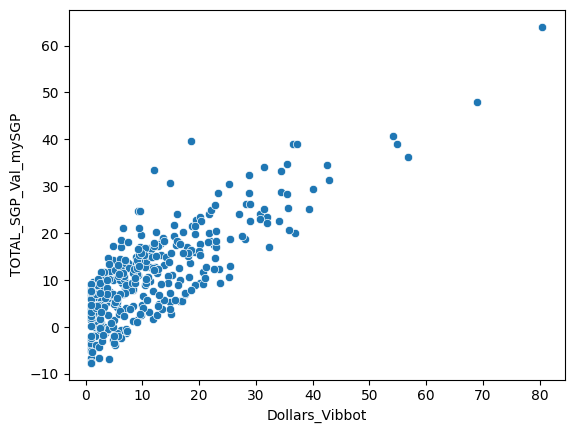

In [145]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Dollars_Vibbot', ylabel='Dollars_FGAV'>

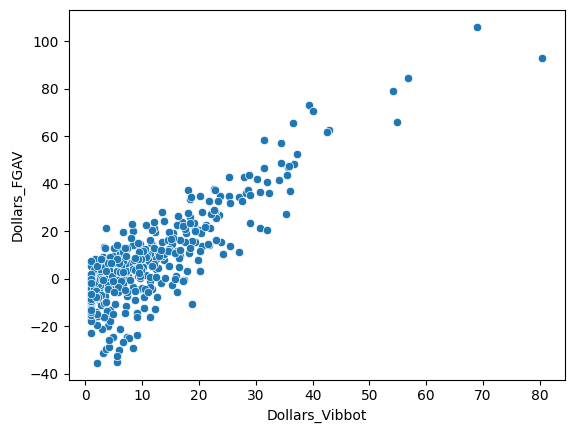

In [146]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='Dollars_FGAV')

# Ottoneu 4x4

In [147]:
Ottoneu_Average_df = pd.read_csv(League_Proj_files['Ottoneu']).drop(columns='Unnamed: 0')

In [148]:
for col in ['Avg Salary','Median Salary','Min Salary','Max Salary','Last 10']:
    Ottoneu_Average_df[col] = Ottoneu_Average_df[col].str.strip('$').astype(float)

In [149]:
Ottoneu_Average_df = Ottoneu_Average_df.rename(
        columns={
            'OttoneuID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions',
            'Avg Salary':'Ottoneu_Avg',
            'Median Salary':'Ottoneu_Med',
            'Min Salary':'Ottoneu_Min',
            'Max Salary':'Ottoneu_Max',
            'Last 10':'Ottoneu_L10',
        }
    )

In [150]:
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].astype(str)
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].str.replace('.0','')

In [151]:
Ottoneu_Average_df = Ottoneu_Average_df[[
    'Ottoneu ID',
    'Ottoneu_Avg',
    'Ottoneu_Med',
    'Ottoneu_Min',
    'Ottoneu_Max',
    'Ottoneu_L10',
    'Roster%'
]].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [152]:
Ottoneu_Average_df.shape

(871, 10)

In [153]:
Ottoneu_Average_df.head()

,Ottoneu ID,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,FG ID,Ottoneu Positions,Name
0,33600,77.33,77.5,60.0,89.0,61.0,100.000,19755,Util/SP,Shohei Ohtani
1,18312,71.50,71.0,54.0,85.0,49.9,100.000,15640,OF,Aaron Judge
2,23717,69.48,70.0,59.0,81.0,69.9,95.833,20123,OF,Juan Soto
3,18276,57.31,60.5,33.0,68.0,49.5,66.667,13611,SS,Mookie Betts
4,23795,52.00,51.0,25.0,68.0,42.1,83.333,19556,OF,Yordan Alvarez


In [154]:
Ottoneu_Average_df.columns

Index(['Ottoneu ID', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'FG ID', 'Ottoneu Positions',
       'Name'],
      dtype='str')

In [155]:
Full_Merge_df = Full_Merge_df.merge(Ottoneu_Average_df,how='outer')

<Axes: xlabel='Ottoneu_Avg', ylabel='TOTAL_SGP_Val_mySGP'>

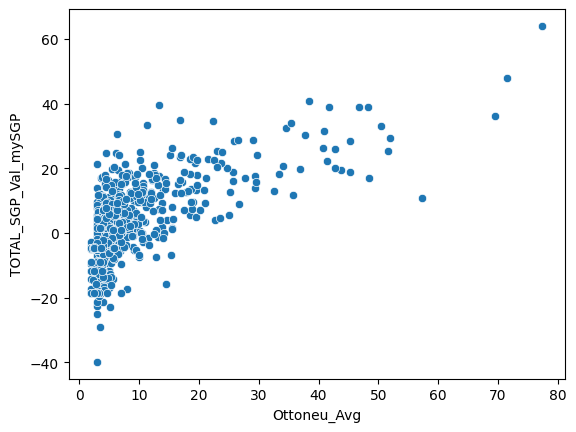

In [156]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_FGAV'>

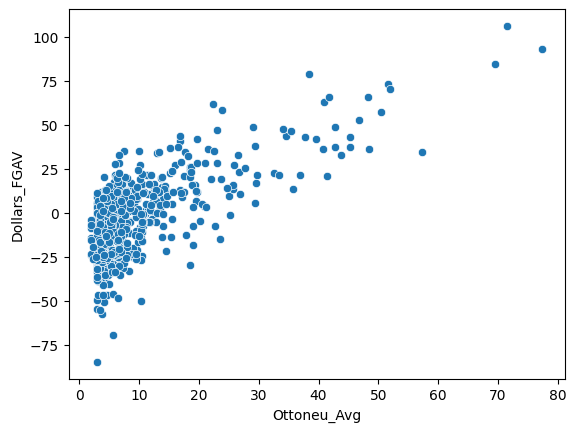

In [157]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_FGAV')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_Vibbot'>

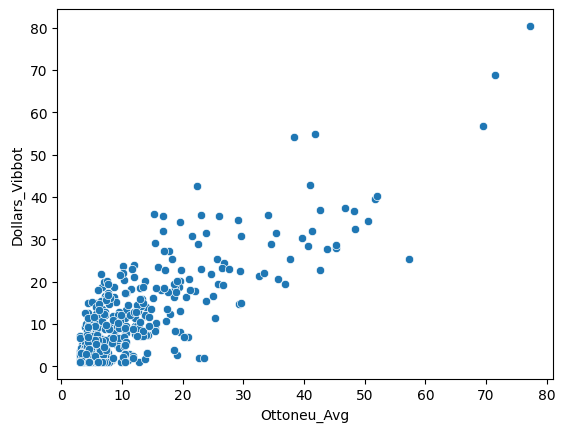

In [158]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_Vibbot')

In [159]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%


In [160]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%


# League Rosters

In [161]:
League_Rosters_df = pd.read_csv(League_Proj_files['Rosters']).drop(columns='Unnamed: 0')


In [162]:
League_Rosters_df.head()

,TeamID,Team Name,ottoneu ID,FG MajorLeagueID,FG MinorLeagueID,Name,MLB Team,Position(s),Salary
0,55,Jack Klugman's Second Best Lung,39108,28163.0,sa3015532,Junior Caminero,TBR,3B,34
1,55,Jack Klugman's Second Best Lung,40927,30116.0,sa3018052,Seiya Suzuki,CHC,OF,33
2,55,Jack Klugman's Second Best Lung,37094,27676.0,sa1115762,Vinnie Pasquantino,KCR,1B,17
3,55,Jack Klugman's Second Best Lung,46310,35466.0,sa3043900,Payton Tolle,BOS,SP/RP,15
4,55,Jack Klugman's Second Best Lung,36922,25768.0,sa3010152,CJ Abrams,WSN,SS,14


In [163]:
League_Rosters_df = League_Rosters_df.rename(
        columns={
            'ottoneu ID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions'
        }
    )

In [164]:
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].astype(str)
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].str.replace('.0','')

In [165]:
League_Rosters_df = League_Rosters_df[['TeamID','Team Name','Ottoneu ID','Salary']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [166]:
Full_Merge_df.columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'G_mySGP', 'PA_mySGP',
       'AB_mySGP', 'H_mySGP', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       'R_mySGP', 'RBI_mySGP', 'BB_mySGP', 'HBP_mySGP', 'SF_mySGP',
       'WAR_mySGP', 'ADP_mySGP', 'POS_mySGP', 'OBP_mySGP', 'TB_mySGP',
       'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP',
       'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_norm_mySGP', 'OBP_SGP_norm_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'Ottoneu ID',
       'Ottoneu Positions', 'W_mySGP', 'L_mySGP', 'QS_mySGP', 'GS_mySGP',
       'SV_mySGP', 'HLD_mySGP', 'IP_mySGP', 'TBF_mySGP', 'ER_mySGP',
       'SO_mySGP', 'K_mySGP', 'HR9_mySGP', 'ERA_mySGP', 'WHIP_mySGP',
       'K_SGP_raw_mySGP', 'HR9_SGP_raw_mySGP', 'ERA_SGP_raw_mySGP',

In [167]:
League_Rosters_df.columns

Index(['TeamID', 'Team Name', 'Ottoneu ID', 'Salary', 'FG ID',
       'Ottoneu Positions', 'Name'],
      dtype='str')

In [168]:
Full_Merge_df = Full_Merge_df.merge(League_Rosters_df,how='outer')

In [169]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


In [170]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


# Full Merge

In [171]:
Full_Merge_df.columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'G_mySGP', 'PA_mySGP',
       'AB_mySGP', 'H_mySGP', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       'R_mySGP', 'RBI_mySGP', 'BB_mySGP', 'HBP_mySGP', 'SF_mySGP',
       'WAR_mySGP', 'ADP_mySGP', 'POS_mySGP', 'OBP_mySGP', 'TB_mySGP',
       'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP',
       'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_norm_mySGP', 'OBP_SGP_norm_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'Ottoneu ID',
       'Ottoneu Positions', 'W_mySGP', 'L_mySGP', 'QS_mySGP', 'GS_mySGP',
       'SV_mySGP', 'HLD_mySGP', 'IP_mySGP', 'TBF_mySGP', 'ER_mySGP',
       'SO_mySGP', 'K_mySGP', 'HR9_mySGP', 'ERA_mySGP', 'WHIP_mySGP',
       'K_SGP_raw_mySGP', 'HR9_SGP_raw_mySGP', 'ERA_SGP_raw_mySGP',

In [172]:
Full_Merge_df[['FG ID',    'Name',
    'Team',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary']].sort_values(by=['ADP_FGAV']).tail(150)

,FG ID,Name,Team,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
2854,sa3043560,Devin Taylor,ATH,Util,47883,NaN,-18.691297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2855,sa3043596,Kavares Tears,SDP,OF,46306,NaN,-18.691297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2856,sa3043664,Cardell Thibodeaux,SDP,OF,47886,NaN,-18.691297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2857,sa3043700,Justin Thomas,HOU,Util,47887,NaN,-18.691297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2858,sa3044088,Camden Troyer,NYY,OF,47893,NaN,-18.691297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3006,sa918182,Julian Garcia,CIN,Util,32716,NaN,-5.278150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3008,sa918983,Matt Fraizer,BOS,OF,37530,NaN,-18.691297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3009,sa944989,Daison Acosta,SDP,RP,33510,NaN,-2.642284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3010,NaN,JoJo Parker,NaN,Util,47541,NaN,NaN,NaN,NaN,3.0,3.0,3.0,3.0,NaN


In [173]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


In [174]:
Full_Merge_df[Full_Merge_df['Name'].isna()][['FG ID','Ottoneu ID','Name']]

,FG ID,Ottoneu ID,Name


In [175]:
Full_Merge_df.columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'G_mySGP', 'PA_mySGP',
       'AB_mySGP', 'H_mySGP', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       'R_mySGP', 'RBI_mySGP', 'BB_mySGP', 'HBP_mySGP', 'SF_mySGP',
       'WAR_mySGP', 'ADP_mySGP', 'POS_mySGP', 'OBP_mySGP', 'TB_mySGP',
       'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP',
       'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_norm_mySGP', 'OBP_SGP_norm_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'Ottoneu ID',
       'Ottoneu Positions', 'W_mySGP', 'L_mySGP', 'QS_mySGP', 'GS_mySGP',
       'SV_mySGP', 'HLD_mySGP', 'IP_mySGP', 'TBF_mySGP', 'ER_mySGP',
       'SO_mySGP', 'K_mySGP', 'HR9_mySGP', 'ERA_mySGP', 'WHIP_mySGP',
       'K_SGP_raw_mySGP', 'HR9_SGP_raw_mySGP', 'ERA_SGP_raw_mySGP',

In [176]:
Full_Merge_sorted_df = Full_Merge_df[[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]].sort_values(by=['ADP_FGAV'])

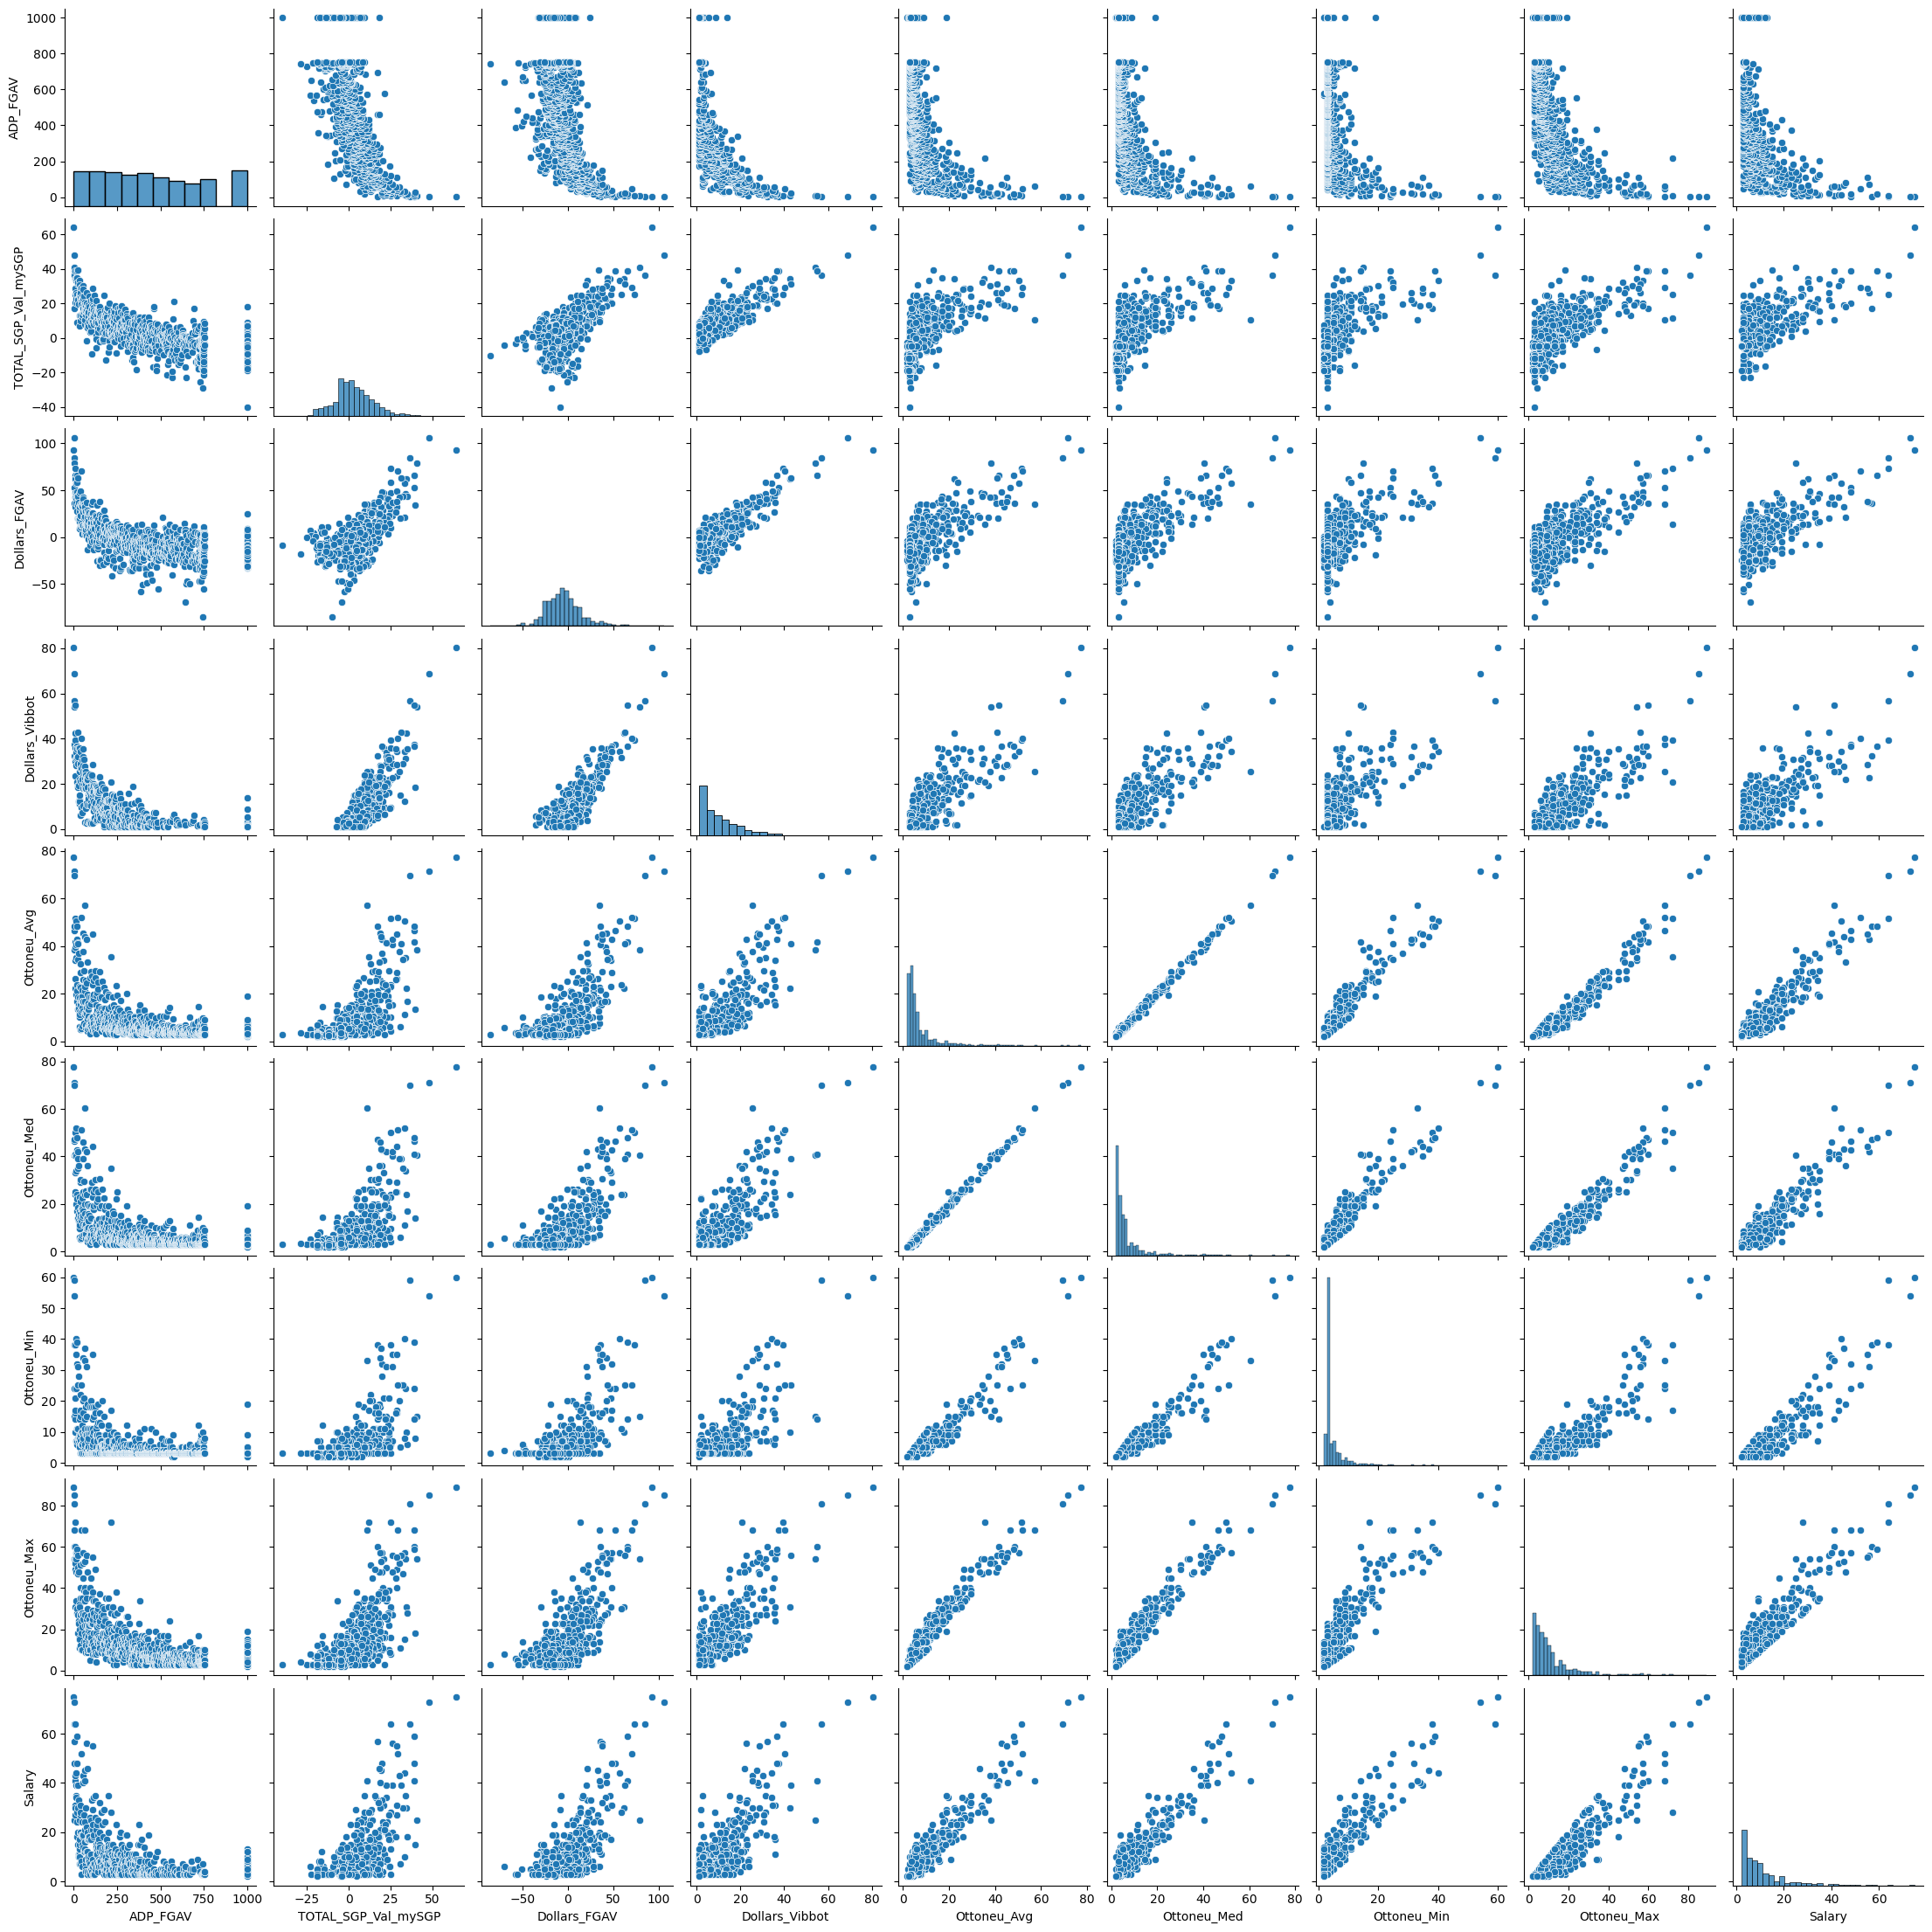

In [177]:
sns.pairplot(Full_Merge_sorted_df[ \
    (Full_Merge_sorted_df['ADP_FGAV'] <= 500) | \
    (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
    (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
    (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
    (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
    (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
    (Full_Merge_sorted_df['Salary'] > 0.)][[
    'Name',
    'Team',
    'Ottoneu Positions',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]])

In [178]:
# Full_Merge_proj_melt_df = Full_Merge_sorted_df[ \
#     (Full_Merge_sorted_df['ADP_FGAV'] <= 500) | \
#     (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
#     (Full_Merge_sorted_df['Salary'] > 0.)][[
#     #'Name',
#     # 'Team',
#     #'Ottoneu Positions',
#     'ADP_FGAV',
#     'TOTAL_SGP_Val_mySGP',
#     'Dollars_FGAV',
#     'Dollars_Vibbot',
#     'Ottoneu_Avg',
#     'Ottoneu_Med', 
#     # 'Ottoneu_Min', 
#     # 'Ottoneu_Max',
#     'Salary'
# ]].melt('ADP_FGAV',var_name='Projection',value_name='Dollars')



In [179]:
# sns.scatterplot(data=Full_Merge_proj_melt_df[Full_Merge_proj_melt_df['ADP_FGAV'] <= 50], x='ADP_FGAV', y='Dollars',hue='Projection')

In [180]:
Full_Merge_sorted_df

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
482,Shohei Ohtani,LAD,154.0,The Rime of Jamie Moyer,Util/SP,33600,1.11,64.001812,92.959461,80.4,77.33,77.5,60.0,89.0,75.0
193,Aaron Judge,NYY,197.0,St. CGT VI,OF,18312,1.97,47.965727,106.144354,68.9,71.50,71.0,54.0,85.0,73.0
926,Bobby Witt Jr.,KCR,236.0,Yoshi Teddy Bear,SS,36668,3.28,38.960073,52.548340,37.3,46.71,46.5,24.0,68.0,48.0
548,Juan Soto,NYM,197.0,St. CGT VI,OF,23717,4.47,36.295703,84.640539,56.8,69.48,70.0,59.0,81.0,64.0
99,José Ramírez,CLE,112.0,Hornswogglers,3B,18284,5.31,17.030058,36.092338,32.3,48.45,47.0,38.0,60.0,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3006,Julian Garcia,CIN,NaN,NaN,Util,32716,NaN,-5.278150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3008,Matt Fraizer,BOS,NaN,NaN,OF,37530,NaN,-18.691297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3009,Daison Acosta,SDP,NaN,NaN,RP,33510,NaN,-2.642284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3010,JoJo Parker,NaN,NaN,NaN,Util,47541,NaN,NaN,NaN,NaN,3.00,3.0,3.0,3.0,NaN


In [181]:
quick_plot = Full_Merge_sorted_df[ \
    (Full_Merge_sorted_df['ADP_FGAV'] <= 50) ]#| \
    # (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
    # (Full_Merge_sorted_df['Salary'] > 0.)]

In [182]:
def quick_plotting_fn(quick_plot):
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(111)
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel('Player')
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    plt.tick_params(axis='y', which='major', labelsize=7)
    plt.show()

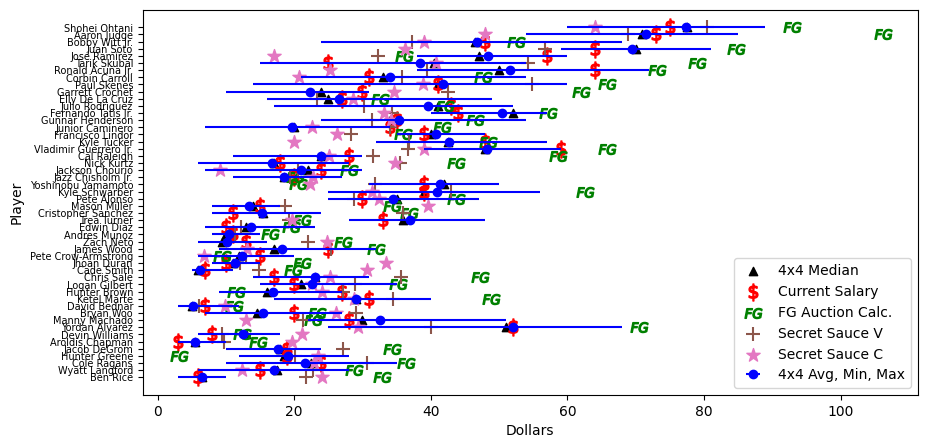

In [183]:
quick_plotting_fn(quick_plot)

In [184]:
Full_Merge_sorted_df[Full_Merge_sorted_df['Name'].str.contains('Wetherholt')]

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
2613,JJ Wetherholt,STL,240.0,Largely Indistinguishables,2B/SS,45713,999.0,5.689691,-11.716184,NaN,5.0,4.5,2.0,11.0,6.0


In [185]:
quick_plot = Full_Merge_sorted_df[Full_Merge_sorted_df['TeamID'] == 197]

In [186]:
quick_plot

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
193,Aaron Judge,NYY,197.0,St. CGT VI,OF,18312,1.970000,47.965727,106.144354,68.9,71.50,71.0,54.0,85.0,73.0
548,Juan Soto,NYM,197.0,St. CGT VI,OF,23717,4.470000,36.295703,84.640539,56.8,69.48,70.0,59.0,81.0,64.0
1033,Garrett Crochet,BOS,197.0,St. CGT VI,SP,38312,10.080000,34.559022,61.984989,42.6,22.33,24.0,10.0,31.0,30.0
454,Yordan Alvarez,HOU,197.0,St. CGT VI,OF,23795,45.860001,29.374440,70.498039,40.1,52.00,51.0,25.0,68.0,52.0
100,Blake Snell,LAD,197.0,St. CGT VI,SP,18460,68.860001,18.709303,13.668387,25.4,25.67,25.5,18.0,38.0,30.0
180,Nick Pivetta,SDP,197.0,St. CGT VI,SP,19398,86.419998,15.275847,-1.760471,13.3,10.63,10.0,5.0,17.0,10.0
110,Corey Seager,TEX,197.0,St. CGT VI,SS,18216,108.419998,28.549271,37.435677,28.7,45.20,44.0,35.0,55.0,55.0
8,Zack Wheeler,PHI,197.0,St. CGT VI,SP,15962,147.779999,17.447224,37.972307,22.6,29.44,30.5,16.0,37.0,32.0
736,Lawrence Butler,ATH,197.0,St. CGT VI,OF,34788,163.389999,3.285440,7.586367,11.2,9.54,9.0,5.0,17.0,13.0
558,Griffin Jax,TBR,197.0,St. CGT VI,RP,31438,173.029999,24.663725,14.916013,9.3,6.11,6.0,5.0,9.0,6.0


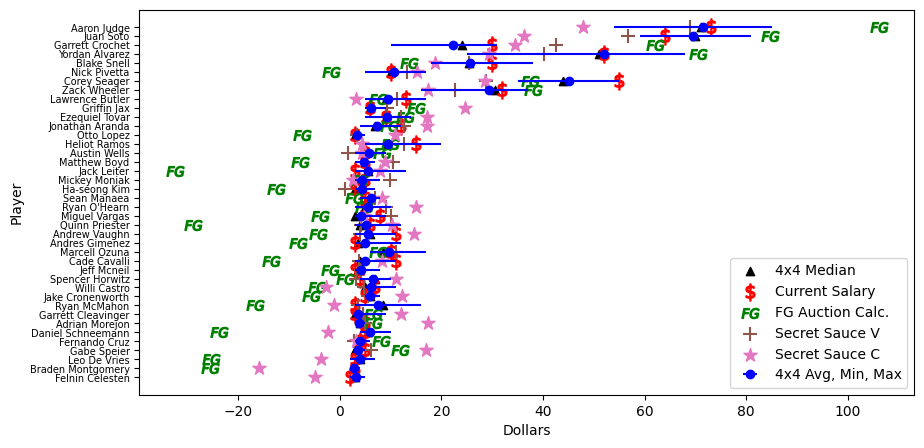

In [93]:
quick_plotting_fn(quick_plot)

In [95]:
quick_plot = Full_Merge_sorted_df[Full_Merge_sorted_df['TeamID'] == 240]

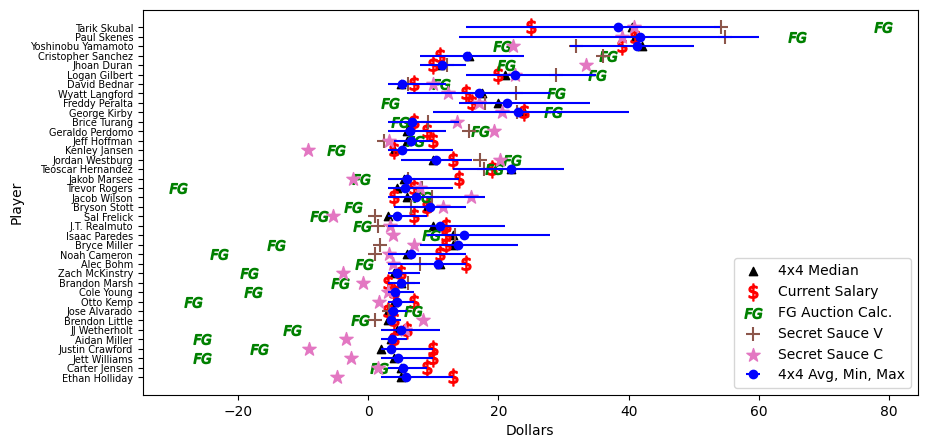

In [96]:
quick_plotting_fn(quick_plot)